# ADASYN

### 1) Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### 2) Load the dataset

In [2]:
df = pd.read_csv("Dataset/dataset_adasyn.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (1384164, 830)


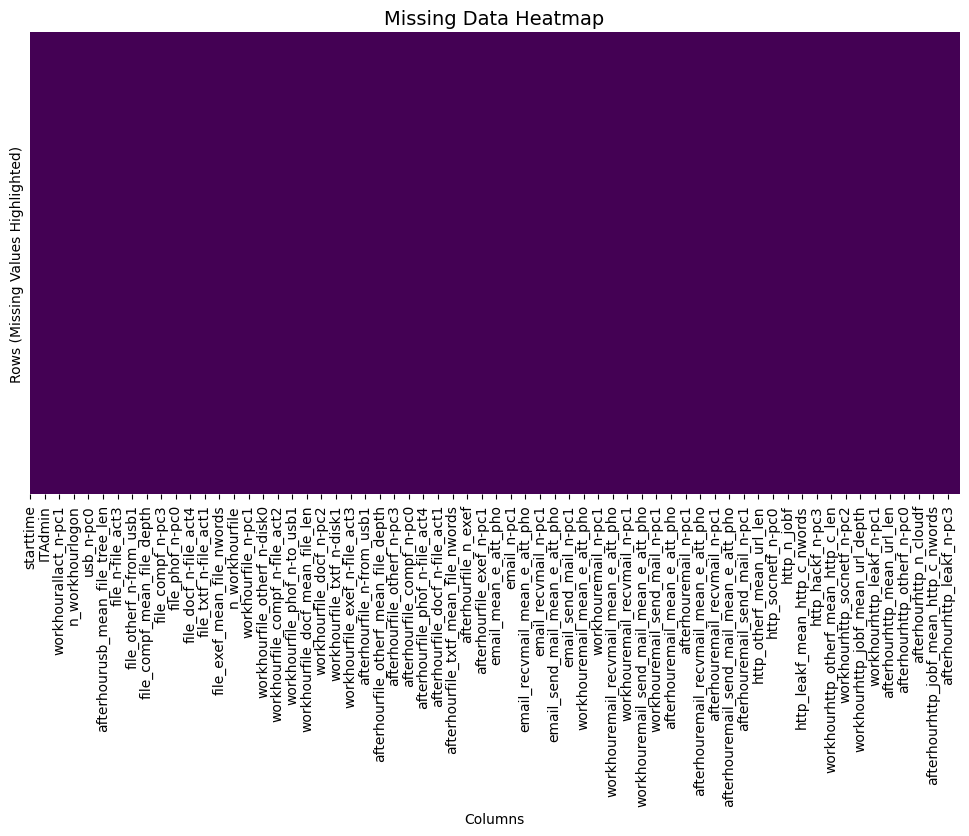

In [4]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title("Missing Data Heatmap", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows (Missing Values Highlighted)")
plt.show()

In [3]:
X = df.drop(columns=['insider'])
y = df['insider']

In [33]:
features = list(X.columns)

### 3) Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train: ", X_train.shape)
print("Test: ", X_test.shape)

Train:  (1107331, 829)
Test:  (276833, 829)


### 4) Standardization

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 5) PCA

In [13]:
from sklearn.decomposition import PCA

pca_lr = PCA(n_components=1)

X_train_pca_lr = pca_lr.fit_transform(X_train)
X_test_pca_lr = pca_lr.transform(X_test)

pca_nb = PCA(n_components=75)

X_train_pca_nb = pca_nb.fit_transform(X_train)
X_test_pca_nb = pca_nb.transform(X_test)

pca_dt = PCA(n_components=50)

X_train_pca_dt = pca_dt.fit_transform(X_train)
X_test_pca_dt = pca_dt.transform(X_test)

pca_rf = PCA(n_components=10)

X_train_pca_rf = pca_rf.fit_transform(X_train)
X_test_pca_rf = pca_rf.transform(X_test)

pca_adb = PCA(n_components=50, random_state=30)

X_train_pca_adb = pca_adb.fit_transform(X_train)
X_test_pca_adb = pca_adb.transform(X_test)

### 6) ML Models

In [7]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=0.02, 
    max_iter=2000, 
    class_weight={0: 1.235, 1: 1.0}, 
    random_state=42
)

lr.fit(X_train_pca_lr, y_train)
y_pred_lr = lr.predict(X_test_pca_lr)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.1%}")
print(classification_report(y_test, y_pred_lr, target_names=['NO', 'YES']))

Logistic Regression
Accuracy: 59.2%
              precision    recall  f1-score   support

          NO       0.57      0.78      0.66    138469
         YES       0.65      0.41      0.50    138364

    accuracy                           0.59    276833
   macro avg       0.61      0.59      0.58    276833
weighted avg       0.61      0.59      0.58    276833



In [8]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB().fit(X_train_pca_nb, y_train)

probs = nb.predict_nb = nb.predict_proba(X_test_pca_nb)[:, 1]

threshold = 0.9823
y_pred_nb = (probs > threshold).astype(int)

print("Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.1%}")
print(classification_report(y_test, y_pred_nb, target_names=['NO', 'YES']))

Naive Bayes
Accuracy: 79.8%
              precision    recall  f1-score   support

          NO       0.72      0.97      0.83    138469
         YES       0.95      0.63      0.76    138364

    accuracy                           0.80    276833
   macro avg       0.84      0.80      0.79    276833
weighted avg       0.84      0.80      0.79    276833



In [9]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=16,
    min_samples_leaf=10, 
    random_state=30
)

dt.fit(X_train_pca_dt, y_train)
probs = dt.predict_proba(X_test_pca_dt)[:, 1]

threshold = 0.8
y_pred_dt = (probs > threshold).astype(int)

print("Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.1%}")
print(classification_report(y_test, y_pred_dt, target_names=['NO', 'YES']))

Decision Tree
Accuracy: 97.8%
              precision    recall  f1-score   support

          NO       0.98      0.97      0.98    138469
         YES       0.98      0.98      0.98    138364

    accuracy                           0.98    276833
   macro avg       0.98      0.98      0.98    276833
weighted avg       0.98      0.98      0.98    276833



In [10]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15, 
    min_samples_leaf=5,
    random_state=30,
    n_jobs=-1
)

rf.fit(X_train_pca_rf, y_train)
probs = rf.predict_proba(X_test_pca_rf)[:, 1]

threshold = 0.66
y_pred_rf = (probs > threshold).astype(int)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.1%}")
print(classification_report(y_test, y_pred_rf, target_names=['NO', 'YES']))

Random Forest
Accuracy: 98.0%
              precision    recall  f1-score   support

          NO       0.98      0.98      0.98    138469
         YES       0.98      0.98      0.98    138364

    accuracy                           0.98    276833
   macro avg       0.98      0.98      0.98    276833
weighted avg       0.98      0.98      0.98    276833



In [14]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils import resample

X_train_small, y_train_small = resample(
    X_train_pca_adb,
    y_train,
    n_samples=75000,
    stratify=y_train,
    random_state=30
)

base_tree = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_leaf=2,
    random_state=30
)

ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=80, 
    learning_rate=0.5,
    random_state=30
)

ada.fit(X_train_small, y_train_small)
y_pred_ada = ada.predict(X_test_pca_adb)

print("AdaBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.1%}")
print(classification_report(y_test, y_pred_ada, target_names=['NO', 'YES']))

AdaBoost
Accuracy: 98.1%
              precision    recall  f1-score   support

          NO       0.99      0.98      0.98    138469
         YES       0.98      0.99      0.98    138364

    accuracy                           0.98    276833
   macro avg       0.98      0.98      0.98    276833
weighted avg       0.98      0.98      0.98    276833



### 7) Ensemble Learning

In [15]:
pca_ens = PCA(n_components = 50)

In [16]:
X_train_ens, y_train_ens = resample(
    X_train,
    y_train,
    n_samples=75000,
    stratify=y_train,
    random_state=30
)

print("Ensemble Training Shape:", X_train_ens.shape)

Ensemble Training Shape: (75000, 829)


In [17]:
X_train_ens = pca_ens.fit_transform(X_train_ens)
X_test_ens = pca_ens.transform(X_test)

print(X_train_ens.shape)

(75000, 50)


In [18]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators = [
        ('dt', dt),
        ('rf', rf),
        ('ada', ada)
    ],
    voting='soft',
    weights=[1, 3, 1], 
    n_jobs=-1
)

voting.fit(X_train_ens, y_train_ens)
y_pred_vote = voting.predict(X_test_ens)

print("\nVoting Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_vote):.1%}")
print(classification_report(y_test, y_pred_vote, target_names=['NO', 'YES']))

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version 


Voting Classifier
Accuracy: 97.8%
              precision    recall  f1-score   support

          NO       0.99      0.97      0.98    138469
         YES       0.97      0.99      0.98    138364

    accuracy                           0.98    276833
   macro avg       0.98      0.98      0.98    276833
weighted avg       0.98      0.98      0.98    276833



In [32]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('adb', ada)
    ],
    final_estimator=LogisticRegression(C=20, max_iter=10000, class_weight='balanced'),
    passthrough=True,
    cv=10, 
    n_jobs=-1
)

stack.fit(X_train_ens, y_train_ens)
y_pred_stack = stack.predict(X_test_ens)

print("\nStacking Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.0%}")
print(classification_report(y_test, y_pred_stack, target_names=['NO','YES'], digits=2))

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version 


Stacking Classifier
Accuracy: 99%
              precision    recall  f1-score   support

          NO       0.99      0.99      0.99    138469
         YES       0.99      0.99      0.99    138364

    accuracy                           0.99    276833
   macro avg       0.99      0.99      0.99    276833
weighted avg       0.99      0.99      0.99    276833



In [34]:
import joblib

joblib.dump({
    "scaler": scaler,
    "pca": pca_ens,
    "model": voting,
    "features": features
}, "adasyn_voting_model.pkl")

['adasyn_voting_model.pkl']

In [35]:
joblib.dump({
    "scaler": scaler,
    "pca": pca_ens,
    "model": stack,
    "features": features
}, "adasyn_stacking_model.pkl")

['adasyn_stacking_model.pkl']

### 8) Visualization

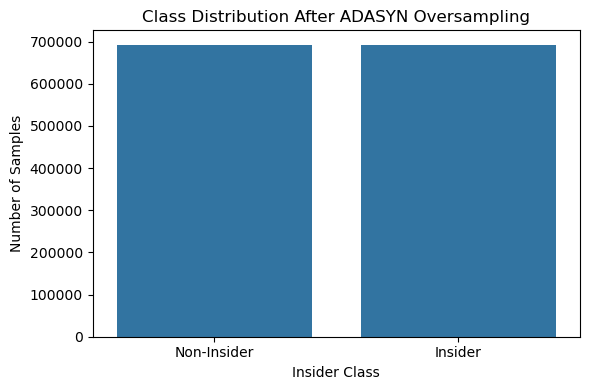

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='insider', data=df)

plt.title("Class Distribution After ADASYN Oversampling")
plt.xlabel("Insider Class")
plt.ylabel("Number of Samples")

plt.xticks([0,1], ['Non-Insider','Insider'])

plt.tight_layout()
plt.savefig("class_dist_adasyn.png", dpi=300, bbox_inches='tight')
plt.show()